# ⚽ FIFA World Cup 2026 Predictive Analytics & Operational Simulation Pipeline
**Framework:** Supervised Multi-Class Classification & Rolling Time-Series Feature Engineering  

---

### 📊 Project Overview
This production-grade pipeline is designed to forecast international football match outcomes and simulate the complete, expanded **FIFA World Cup 2026** tournament structure. By engineering high-frequency team momentum metrics (rolling historical form) and blending them with long-term skill indicators (World Football Elo Ratings), the architecture maps predictive structural inputs to multi-class match outcomes (Home Win, Draw, Away Win).

### ⚙️ Production & Architecture Highlights
* **Temporal Integrity Protection:** Team form features are strictly lagged ($t-1$) before model training to eliminate look-ahead bias and protect against downstream data leakage.
* **Generalization via 5-Fold Cross-Validation:** Shifting beyond volatile, single train/test splits to accurately benchmark model resilience across the entire historical timeline.
* **Out-of-Sample Deterministic Simulation:** Built a custom simulation engine that perfectly mirrors official FIFA regulations and Wikipedia tournament bracket connectivity pathways.

In [1]:
# =========================================================================
# SECTION 1: SYSTEM DEPENDENCY INGESTION & PIPELINE INITIALIZATION
# =========================================================================
import pandas as pd
import numpy as np
from itertools import combinations

# Core Model Architecture & Evaluation Utilities
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Diagnostic Analytics Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# Inline plotting configuration for Jupyter environments
%matplotlib inline

### 📋 Section 2: Data Ingestion & Schema Standardization
* **Objective:** Load historical match databases and global Elo ratings, clean missing records, and enforce strict type casting for dates and metrics.

In [2]:
results = pd.read_csv("data/results.csv")
shootouts = pd.read_csv("data/shootouts.csv")
eloratings = pd.read_csv("data/eloratings.csv")
former_names = pd.read_csv("data/former_names.csv")

DATA CLEANING, TYPE STANDARDIZATION & PREPROCESSING

In [3]:
results.shape

(49287, 9)

In [4]:
results.dtypes

date           object
home_team      object
away_team      object
home_score    float64
away_score    float64
tournament     object
city           object
country        object
neutral          bool
dtype: object

In [5]:
results.isna().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [6]:
results['date']= pd.to_datetime(results['date'])
results.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

In [7]:
results[results['home_score'].isna()].head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49215,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49216,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49217,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49218,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49219,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True


In [8]:
results.dropna(subset=['home_score','away_score'], inplace = True)

In [9]:
results.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [10]:
results['home_score'] = results['home_score'].astype(int)
results['away_score'] = results['away_score'].astype(int)

In [11]:
results.duplicated().sum()

np.int64(0)

In [12]:
# Check how many duplicate matches exist based on date and teams
duplicates_count = results.duplicated(subset=['date', 'home_team', 'away_team']).sum()
print(f"Duplicate matches found: {duplicates_count}")

# Drop the duplicate, keeping the first instance
results.drop_duplicates(subset=['date', 'home_team', 'away_team'], keep='first', inplace=True)
print("Duplicates removed!")

Duplicate matches found: 1
Duplicates removed!


In [13]:
results.dtypes

date          datetime64[ns]
home_team             object
away_team             object
home_score             int64
away_score             int64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

In [14]:
shootouts.dtypes
shootouts.duplicated().sum()

np.int64(0)

In [15]:
shootouts.duplicated(subset=['date', 'home_team', 'away_team']).sum()

np.int64(0)

In [16]:
shootouts['date']=pd.to_datetime(shootouts['date'])
shootouts.dtypes

date             datetime64[ns]
home_team                object
away_team                object
winner                   object
first_shooter            object
dtype: object

In [17]:
shootouts.drop(columns=['first_shooter'], inplace=True)
shootouts.head()

,date,home_team,away_team,winner
0,1967-08-22,India,Taiwan,Taiwan
1,1971-11-14,South Korea,Vietnam Republic,South Korea
2,1972-05-07,South Korea,Iraq,Iraq
3,1972-05-17,Thailand,South Korea,South Korea
4,1972-05-19,Thailand,Cambodia,Thailand


In [18]:
eloratings.dtypes
eloratings.tail()

,date,team,rating,change
6673,12/13/2025,Northern Mariana Islands,432.0,0
6674,12/13/2025,Cocos Islands,422.0,0
6675,12/13/2025,Palau,402.0,0
6676,12/13/2025,Eastern Samoa,389.0,0
6677,12/13/2025,Moldova,0.0,0


In [19]:
eloratings['date'] = pd.to_datetime(eloratings['date'], format='mixed')
eloratings.dtypes

date      datetime64[ns]
team              object
rating           float64
change             int64
dtype: object

In [20]:
eloratings.duplicated(subset=['date','team']).sum()

np.int64(0)

In [21]:
eloratings.shape

(6678, 4)

In [22]:
eloratings.tail()

,date,team,rating,change
6673,2025-12-13,Northern Mariana Islands,432.0,0
6674,2025-12-13,Cocos Islands,422.0,0
6675,2025-12-13,Palau,402.0,0
6676,2025-12-13,Eastern Samoa,389.0,0
6677,2025-12-13,Moldova,0.0,0


In [23]:
sorted(eloratings['team'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua\xa0and\xa0Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire',
 'Bosnia\xa0and\xa0Herzegovina',
 'Botswana',
 'Brazil',
 'British\xa0Guiana',
 'British\xa0Virgin\xa0Islands',
 'Brunei',
 'Bulgaria',
 'Burkina\xa0Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape\xa0Verde',
 'Cayman\xa0Islands',
 'Central\xa0African\xa0Republic',
 'Ceylon',
 'Chad',
 'Chagos\xa0Islands',
 'Chile',
 'China',
 'Christmas\xa0Island',
 'Cocos\xa0Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo-Brazzaville',
 'Cook\xa0Islands',
 'Costa\xa0Rica',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czechia',
 'Czechoslovakia',
 'Dahomey',
 'Democratic\xa0Republic\xa0of\xa0Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican\xa

In [24]:
# Replace HTML non-breaking spaces with normal spaces in the Elo dataset
eloratings['team'] = eloratings['team'].str.replace('\xa0', ' ')

In [25]:
sorted(eloratings['team'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Guiana',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burma',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Ceylon',
 'Chad',
 'Chagos Islands',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo-Brazzaville',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czechia',
 'Czechoslovakia',
 'Dahomey',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Eastern Samoa',
 

In [26]:
sorted(results['home_team'].unique())

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde',
 'Cascadia',
 'Catalonia',
 'Cayman Islands',
 'Central African Republic',
 'Central Spain',
 'Chad',
 'Chagos Islands',
 'Chameria',
 'Chechnya',
 'Chile',
 'China PR',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Corsica',
 'Costa Rica',
 'County of Nice',
 'Croatia',
 'Cuba',
 'Curaçao',
 'Cyprus',
 'Czech 

In [27]:
# 1. Get a unique set of every team that played a match
results_teams = set(results['home_team']).union(set(results['away_team']))

# 2. Get a unique set of every team that has an Elo rating
elo_teams = set(eloratings['team'])

# 3. Find the difference! (Teams in results that DO NOT exist in eloratings)
missing_elo = sorted(results_teams - elo_teams)

print(f"Found {len(missing_elo)} teams in results.csv with NO matching Elo rating:")
print("-" * 50)
for team in missing_elo:
    print(team)

Found 104 teams in results.csv with NO matching Elo rating:
--------------------------------------------------
Abkhazia
Alderney
Ambazonia
American Samoa
Andalusia
Arameans Suryoye
Artsakh
Asturias
Aymara
Barawa
Basque Country
Biafra
Brittany
Canary Islands
Cascadia
Catalonia
Central Spain
Chameria
Chechnya
China PR
Cilento
Corsica
County of Nice
Crimea
Czech Republic
DR Congo
Darfur
Donetsk PR
Délvidék
Elba Island
Ellan Vannin
Felvidék
Franconia
Frøya
Galicia
German DR
Gotland
Gozo
Guernsey
Găgăuzia
Hitra
Hmong
Iraqi Kurdistan
Isle of Man
Isle of Wight
Jersey
Kabylia
Kernow
Kárpátalja
Luhansk PR
Macau
Madrid
Manchukuo
Mapuche
Matabeleland
Maule Sur
Menorca
Micronesia
Occitania
Orkney
Padania
Panjab
Parishes of Jersey
Provence
Raetia
Republic of Ireland
Republic of St. Pauli
Rhodes
Romani people
Ryūkyū
Réunion
Saare County
Saarland
Saint Barthélemy
Saint Helena
Sark
Saugeais
Sealand
Seborga
Shetland
Silesia
South Ossetia
Surrey
Székely Land
Sápmi
São Tomé and Príncipe
Tamil Eelam
Ticin

# Map Team Names

In [28]:
#Number of Eswatini Before Mapping
eloratings[eloratings['team']=='Eswatini'].shape[0]

7

In [29]:
# 1. Create a mapping dictionary: { 'former_name': 'current_name' }
name_map = dict(zip(former_names["former"], former_names["current"]))

# 2. Intercept and remove the problematic historical mapping
name_map.pop('Ireland', None)

# Add manual fixes for teams that just use different names
custom_fixes = {
    "China PR": "China",
    "Czech Republic": "Czechia",
    "DR Congo": "Democratic Republic of Congo",
    "Republic of Ireland": "Ireland",
    "Macau": "Macao",
    "Cape Verde Islands": "Cape Verde",
    "Korea DPR": "North Korea",
    "Curaçao": "Curacao"
}
name_map.update(custom_fixes)

In [30]:
swazi_before = eloratings[eloratings['team'] == 'Swaziland'].shape[0]
print(f"BEFORE MAPPING:")
print(f"  Elo records for 'Swaziland': {swazi_before}")

BEFORE MAPPING:
  Elo records for 'Swaziland': 17


In [31]:
# 2. Apply the mappings across the datasets
for df in [results, shootouts]:
    df['home_team'] = df['home_team'].replace(name_map)
    df['away_team'] = df['away_team'].replace(name_map)

eloratings['team'] = eloratings['team'].replace(name_map)

In [32]:
swazi_after = eloratings[eloratings['team'] == 'Swaziland'].shape[0]
print(f"\nAFTER MAPPING:")
print(f"  Elo records for 'Swaziland': {swazi_after}")
print("✅ Geopolitics resolved! Names standardized successfully.")


AFTER MAPPING:
  Elo records for 'Swaziland': 0
✅ Geopolitics resolved! Names standardized successfully.


In [33]:
eloratings[eloratings['team']=='Swaziland'] #after name change

,date,team,rating,change


In [34]:
#Number of Eswatini After Mapping Shows that it Worked!
eloratings[eloratings['team']=='Eswatini'].shape[0]

24

In [35]:
sorted(results['home_team'].unique())

['Abkhazia',
 'Afghanistan',
 'Albania',
 'Alderney',
 'Algeria',
 'American Samoa',
 'Andalusia',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Arameans Suryoye',
 'Argentina',
 'Armenia',
 'Artsakh',
 'Aruba',
 'Australia',
 'Austria',
 'Aymara',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barawa',
 'Barbados',
 'Basque Country',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Biafra',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brittany',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Canary Islands',
 'Cape Verde',
 'Cascadia',
 'Catalonia',
 'Cayman Islands',
 'Central African Republic',
 'Central Spain',
 'Chad',
 'Chagos Islands',
 'Chameria',
 'Chechnya',
 'Chile',
 'China',
 'Colombia',
 'Comoros',
 'Congo',
 'Cook Islands',
 'Corsica',
 'Costa Rica',
 'County of Nice',
 'Croatia',
 'Cuba',
 'Curacao',
 'Cyprus',
 'Czechia',

In [36]:
sorted(eloratings['team'].unique())

['Afghanistan',
 'Albania',
 'Algeria',
 'Andorra',
 'Angola',
 'Anguilla',
 'Antigua and Barbuda',
 'Argentina',
 'Armenia',
 'Aruba',
 'Australia',
 'Austria',
 'Azerbaijan',
 'Bahamas',
 'Bahrain',
 'Bangladesh',
 'Barbados',
 'Belarus',
 'Belgium',
 'Belize',
 'Benin',
 'Bermuda',
 'Bhutan',
 'Bolivia',
 'Bonaire',
 'Bosnia and Herzegovina',
 'Botswana',
 'Brazil',
 'British Virgin Islands',
 'Brunei',
 'Bulgaria',
 'Burkina Faso',
 'Burundi',
 'Cambodia',
 'Cameroon',
 'Canada',
 'Cape Verde',
 'Cayman Islands',
 'Central African Republic',
 'Chad',
 'Chagos Islands',
 'Chile',
 'China',
 'Christmas Island',
 'Cocos Islands',
 'Colombia',
 'Comoros',
 'Congo',
 'Congo-Brazzaville',
 'Cook Islands',
 'Costa Rica',
 'Croatia',
 'Cuba',
 'Curacao',
 'Curaçao',
 'Cyprus',
 'Czechia',
 'Czechoslovakia',
 'Democratic Republic of Congo',
 'Denmark',
 'Djibouti',
 'Dominica',
 'Dominican Republic',
 'East Germany',
 'East Timor',
 'Eastern Samoa',
 'Ecuador',
 'Egypt',
 'El Salvador',
 'E

## Create the Target Variable (Match Result)

In [37]:
# 1. Merge the shootout winner into the results dataset
# We use a 'left' join so we keep all matches, but add shootout data if it exists
results = results.merge(
    shootouts[['date', 'home_team', 'away_team', 'winner']], 
    on=['date', 'home_team', 'away_team'], 
    how='left'
)

# 2. Define a function to calculate the true final result
def get_result(row):
    # Standard win/loss in regular or extra time
    if row["home_score"] > row["away_score"]: return "home_win"
    if row["away_score"] > row["home_score"]: return "away_win"
    
    # If the score was tied, check if someone won in a shootout
    if pd.notna(row["winner"]):
        return "home_win" if row["winner"] == row["home_team"] else "away_win"
    
    # If no one won and there was no shootout, it is a true draw
    return "draw"

# 3. Apply the function row by row
results['result'] = results.apply(get_result, axis=1)

print("✅ Target Variable Created!")
print("\nMatch Outcomes Distribution:")
print(results['result'].value_counts(normalize=True) * 100)

✅ Target Variable Created!

Match Outcomes Distribution:
result
home_win    49.664730
away_win    28.877962
draw        21.457309
Name: proportion, dtype: float64


In [38]:
shootouts.tail()

,date,home_team,away_team,winner
670,2026-03-30,Cape Verde,Finland,Cape Verde
671,2026-03-30,Gabon,Trinidad and Tobago,Gabon
672,2026-03-30,Uzbekistan,Venezuela,Uzbekistan
673,2026-03-31,Bosnia and Herzegovina,Italy,Bosnia and Herzegovina
674,2026-03-31,Czechia,Denmark,Czech Republic


In [39]:
eloratings[eloratings['team'] == 'United States'].tail()

,date,team,rating,change
6083,2025-06-07,United States,1713.0,-10
6148,2025-06-10,United States,1695.0,-18
6268,2025-09-09,United States,1698.0,19
6351,2025-11-18,United States,1747.0,24
6467,2025-12-13,United States,1747.0,0


In [40]:
eloratings[eloratings['team'] == 'Paraguay'].tail()

,date,team,rating,change
5751,2023-10-12,Paraguay,1703.0,-2
6131,2025-06-10,Paraguay,1825.0,-7
6258,2025-09-09,Paraguay,1844.0,20
6341,2025-11-18,Paraguay,1833.0,11
6454,2025-12-13,Paraguay,1833.0,0


In [41]:
eloratings.isnull().sum()

date       0
team       0
rating    31
change     0
dtype: int64

In [42]:
# Drop all matches where Moldova is either the home team or away team
results = results[(results['home_team'] != 'Moldova') & (results['away_team'] != 'Moldova')]

# Check how many rows are left to confirm it worked
print(f"Total matches after dropping Moldova: {len(results)}")

Total matches after dropping Moldova: 48917


In [43]:
# 1. Time-series merges REQUIRE both datasets to be sorted by time
results = results.sort_values('date')
eloratings = eloratings.sort_values('date')

# 2. Merge Home Team Elo (Finds the most recent rating BEFORE the match)
results = pd.merge_asof(
    results,
    eloratings[['date', 'team', 'rating']].rename(columns={'rating': 'home_elo'}),
    left_on='date',
    right_on='date',
    left_by='home_team',
    right_by='team',
    direction='backward'
).drop(columns=['team'])

# 3. Merge Away Team Elo
results = pd.merge_asof(
    results,
    eloratings[['date', 'team', 'rating']].rename(columns={'rating': 'away_elo'}),
    left_on='date',
    right_on='date',
    left_by='away_team',
    right_by='team',
    direction='backward'
).drop(columns=['team'])

# 4. Calculate the master feature: Elo Difference
results['elo_diff'] = results['home_elo'] - results['away_elo']

In [44]:
results.isnull().sum()

date              0
home_team         0
away_team         0
home_score        0
away_score        0
tournament        0
city              0
country           0
neutral           0
winner        48244
result            0
home_elo       4335
away_elo       4716
elo_diff       6903
dtype: int64

In [45]:
# 5. Filter down to ONLY the FIFA World Cup matches
competitive_tournaments = [
    'FIFA World Cup', 
    'FIFA World Cup qualification', 
    'UEFA Euro', 
    'UEFA Euro qualification',
    'Copa América', 
    'African Cup of Nations', 
    'CONCACAF Gold Cup', 
    'AFC Asian Cup'
]

wc_all = results[results['tournament'].isin(competitive_tournaments)].copy()

# Keep only modern era matches
wc_all = wc_all[wc_all['date'].dt.year >= 2000].copy()

print(f"New Training Dataset Size: {len(wc_all)} matches!")

print("✅ Final Master DataFrame Created!")
print(f"Total Matches: {len(wc_all)}")
print(f"Missing Home Elos: {wc_all['home_elo'].isna().sum()}")
print(f"Missing Away Elos: {wc_all['away_elo'].isna().sum()}")

# Display the clean table
display(wc_all[['date', 'home_team', 'away_team', 'home_elo', 'away_elo', 'elo_diff', 'result']].head())

New Training Dataset Size: 8936 matches!
✅ Final Master DataFrame Created!
Total Matches: 8936
Missing Home Elos: 94
Missing Away Elos: 112


,date,home_team,away_team,home_elo,away_elo,elo_diff,result
24029,2000-01-22,Ghana,Cameroon,1580.0,1663.0,-83.0,draw
24031,2000-01-23,South Africa,Gabon,1728.0,1492.0,236.0,home_win
24032,2000-01-23,Nigeria,Tunisia,1692.0,1621.0,71.0,home_win
24034,2000-01-23,Egypt,Zambia,1616.0,1616.0,0.0,home_win
24036,2000-01-24,Democratic Republic of Congo,Algeria,1681.0,1602.0,79.0,draw


In [46]:
# Isolate the matches that are still missing Elo ratings
missing_final = wc_all[wc_all['home_elo'].isna() | wc_all['away_elo'].isna()]

# Show the dates and teams
display(missing_final[['date', 'home_team', 'away_team', 'home_elo', 'away_elo']].head(15))

,date,home_team,away_team,home_elo,away_elo
24194,2000-03-05,Saint Vincent and the Grenadines,United States Virgin Islands,1249.0,NaN
24197,2000-03-05,El Salvador,Belize,1520.0,NaN
24223,2000-03-18,Saint Kitts and Nevis,Turks and Caicos Islands,1254.0,NaN
24224,2000-03-19,United States Virgin Islands,Saint Vincent and the Grenadines,NaN,1253.0
24236,2000-03-21,Saint Kitts and Nevis,Turks and Caicos Islands,1254.0,NaN
24310,2000-04-08,São Tomé and Príncipe,Sierra Leone,NaN,1526.0
24330,2000-04-09,Eritrea,Nigeria,NaN,1692.0
24366,2000-04-22,Sierra Leone,São Tomé and Príncipe,1526.0,NaN
24371,2000-04-22,Nigeria,Eritrea,1692.0,NaN
24565,2000-06-13,Serbia,Slovenia,NaN,1600.0


In [47]:
# Drop the final historical anomalies
wc_all = wc_all.dropna(subset=['home_elo', 'away_elo']).copy()

print(f"🎉 DATA CLEANING COMPLETE!")
print(f"Final ML Dataset Size: {len(wc_all)} World Cup matches ready for training.")
print(f"Total World Cup Matches: {len(wc_all)}")
print(f"Missing Home Elos: {wc_all['home_elo'].isna().sum()}")
print(f"Missing Away Elos: {wc_all['away_elo'].isna().sum()}")

🎉 DATA CLEANING COMPLETE!
Final ML Dataset Size: 8743 World Cup matches ready for training.
Total World Cup Matches: 8743
Missing Home Elos: 0
Missing Away Elos: 0


In [48]:
eloratings[eloratings['team']== 'United States'].tail()

,date,team,rating,change
6083,2025-06-07,United States,1713.0,-10
6148,2025-06-10,United States,1695.0,-18
6268,2025-09-09,United States,1698.0,19
6351,2025-11-18,United States,1747.0,24
6467,2025-12-13,United States,1747.0,0


In [49]:
eloratings[eloratings['team']== 'Paraguay'].tail()

,date,team,rating,change
5751,2023-10-12,Paraguay,1703.0,-2
6131,2025-06-10,Paraguay,1825.0,-7
6258,2025-09-09,Paraguay,1844.0,20
6341,2025-11-18,Paraguay,1833.0,11
6454,2025-12-13,Paraguay,1833.0,0


# ML

### Chronological Feature Engineering (Rolling Team Momentum)
* **Objective:** Transform the historical match records into a long-form team timeline to compute rolling mathematical windows. 
* **Key Constraint:** A `.shift()` operation is explicitly applied to guarantee that a match played on day $t$ only evaluates performance vectors from history up to day $t-1$, strictly preventing data leakage.

In [50]:
def get_points(result, team_type):
    if result == 'draw': return 1
    if team_type == 'home' and result == 'home_win': return 3
    if team_type == 'away' and result == 'away_win': return 3
    return 0

# 1. Create a long-form version of matches to calculate streaks per team
home_results = results[['date', 'home_team', 'away_team', 'result']].rename(columns={'home_team': 'team', 'away_team': 'opponent'})
home_results['points'] = home_results.apply(lambda x: get_points(x['result'], 'home'), axis=1)

away_results = results[['date', 'away_team', 'home_team', 'result']].rename(columns={'away_team': 'team', 'home_team': 'opponent'})
away_results['points'] = away_results.apply(lambda x: get_points(x['result'], 'away'), axis=1)

# Combine and sort by team and date
all_team_results = pd.concat([home_results, away_results]).sort_values(['team', 'date'])

# -------------------------------------------------------------------------
# QUALITY-WEIGHTED FORM: scale points by opponent's Elo percentile
# Beating a top team gives more credit than beating a weak team.
# -------------------------------------------------------------------------
all_team_results = all_team_results.reset_index(drop=True)

# Merge opponent Elo into the long-form table
all_team_results = pd.merge_asof(
    all_team_results.sort_values('date'),
    eloratings[['date', 'team', 'rating']].rename(columns={'team': 'opponent', 'rating': 'opponent_elo'}),
    on='date',
    by='opponent',
    direction='backward'
)

# Elo percentile rank across all ratings (0.0 = weakest, 1.0 = strongest)
all_rating_values = eloratings['rating'].values
all_team_results['opponent_elo_pct'] = all_team_results['opponent_elo'].apply(
    lambda x: (all_rating_values < x).sum() / len(all_rating_values) if pd.notna(x) else 0.5
)

# Weighted points = raw points × (0.5 + opponent_elo_pct)
# Scale: beating a top-100th-pct team → 3 × 1.5 = 4.5
#        beating a 0th-pct team        → 3 × 0.5 = 1.5
#        drawing a top team            → 1 × 1.5 = 1.5 (still meaningful)
all_team_results['weighted_points'] = all_team_results['points'] * (0.5 + all_team_results['opponent_elo_pct'])

# 2. Rolling 5-game average of weighted points (lagged to prevent leakage)
all_team_results = all_team_results.sort_values(['team', 'date'])
all_team_results['weighted_form_5'] = all_team_results.groupby('team')['weighted_points'].transform(
    lambda x: x.shift().rolling(5).mean()
)

# 3. Merge weighted form back into training dataset
wc_all = wc_all.merge(
    all_team_results[['date', 'team', 'weighted_form_5']],
    left_on=['date', 'home_team'], right_on=['date', 'team'], how='left'
).drop(columns='team').rename(columns={'weighted_form_5': 'home_form'})

wc_all = wc_all.merge(
    all_team_results[['date', 'team', 'weighted_form_5']],
    left_on=['date', 'away_team'], right_on=['date', 'team'], how='left'
).drop(columns='team').rename(columns={'weighted_form_5': 'away_form'})

# Neutral fill: average weighted points for a team with no prior history
avg_weighted_form = all_team_results['weighted_form_5'].mean()
wc_all['home_form'] = wc_all['home_form'].fillna(avg_weighted_form)
wc_all['away_form'] = wc_all['away_form'].fillna(avg_weighted_form)

print("✅ Quality-Weighted Form features created!")
print(f"   Scale: 0 (lost to top team) → ~4.5 (beat top team)")
print(f"   Average weighted form: {avg_weighted_form:.3f}")
display(wc_all[['home_team', 'away_team', 'home_form', 'away_form']].tail())

✅ Quality-Weighted Form features created!
   Scale: 0 (lost to top team) → ~4.5 (beat top team)
   Average weighted form: 1.378


,home_team,away_team,home_form,away_form
8738,Democratic Republic of Congo,Jamaica,1.645882,1.545852
8739,Iraq,Bolivia,1.675921,1.328332
8740,Bosnia and Herzegovina,Italy,2.323929,2.544654
8741,Sweden,Poland,1.053220,2.562025
8742,Kosovo,Turkey,2.830967,2.811231


In [134]:
def add_rolling_goals_conceded(df, window=3):
    """
    Calculates the rolling sum of goals conceded by a team in their last 'n' matches.
    Assumes df has columns: 'date', 'home_team', 'away_team', 'home_score', 'away_score'
    """
    # 1. Ensure the dataset is strictly sorted by date so time-series logic works
    df = df.sort_values('date').copy()
    
    # 2. Extract Home Team performances (Goals Conceded = away_score)
    home_df = df[['date', 'home_team', 'away_score']].copy()
    home_df.rename(columns={'home_team': 'team', 'away_score': 'goals_conceded'}, inplace=True)
    
    # 3. Extract Away Team performances (Goals Conceded = home_score)
    away_df = df[['date', 'away_team', 'home_score']].copy()
    away_df.rename(columns={'away_team': 'team', 'home_score': 'goals_conceded'}, inplace=True)
    
    # 4. Stack them together to create a master timeline of every match played by every team
    team_timeline = pd.concat([home_df, away_df]).sort_values(['team', 'date'])
    
    # 5. Calculate the Rolling Sum
    # - shift(1) ensures we only look at PAST matches, not the current one.
    # - min_periods=1 ensures that even if a team only has 1 or 2 past matches, it still calculates.
    team_timeline['goals_conceded_rolling'] = (
        team_timeline.groupby('team')['goals_conceded']
        .transform(lambda x: x.shift(1).rolling(window=window, min_periods=1).sum())
    )
    
    # 6. Fill NaNs for a team's very first historical match (they have no past matches)
    team_timeline['goals_conceded_rolling'] = team_timeline['goals_conceded_rolling'].fillna(0)
    
    # 7. Merge the metric back to the Home Team in the main dataframe
    df = df.merge(
        team_timeline[['date', 'team', 'goals_conceded_rolling']], 
        left_on=['date', 'home_team'], 
        right_on=['date', 'team'], 
        how='left'
    ).rename(columns={'goals_conceded_rolling': 'home_goals_conceded_rolling'}).drop('team', axis=1)
    
    # 8. Merge the metric back to the Away Team in the main dataframe
    df = df.merge(
        team_timeline[['date', 'team', 'goals_conceded_rolling']], 
        left_on=['date', 'away_team'], 
        right_on=['date', 'team'], 
        how='left'
    ).rename(columns={'goals_conceded_rolling': 'away_goals_conceded_rolling'}).drop('team', axis=1)
    
    return df

# --- How to use it in your pipeline ---
# df = add_rolling_goals_conceded(df, window=3)

In [137]:
rolling_goals = add_rolling_goals_conceded(results, window=3)

In [140]:
# Create the single feature for the Random Forest
rolling_goals['defensive_fragility_diff'] = rolling_goals['home_goals_conceded_rolling'] - rolling_goals['away_goals_conceded_rolling']

# Positive number = Home team is defensively weaker lately.
# Negative number = Away team is defensively weaker lately.

In [141]:
rolling_goals.tail()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,result,home_elo,away_elo,elo_diff,home_goals_conceded_rolling,away_goals_conceded_rolling,defensive_fragility_diff
49240,2026-03-31,Cameroon,China,2,0,FIFA Series,Melbourne,Australia,True,NaN,home_win,1559.0,1403.0,156.0,4.0,2.0,2.0
49241,2026-03-31,Peru,Honduras,2,2,Friendly,Madrid,Spain,True,NaN,draw,1698.0,1567.0,131.0,5.0,2.0,3.0
49242,2026-03-31,United States,Portugal,0,2,Friendly,Atlanta,United States,False,NaN,away_win,1747.0,1976.0,-229.0,7.0,3.0,4.0
49243,2026-03-31,Australia,Curacao,5,1,FIFA Series,Melbourne,Australia,False,NaN,home_win,1774.0,1467.0,307.0,4.0,2.0,2.0
49244,2026-03-31,Kazakhstan,Comoros,1,0,FIFA Series,Astana,Kazakhstan,False,NaN,home_win,1410.0,1359.0,51.0,2.0,0.0,2.0


In [144]:
# 1. Extract every team's most recent matches (both as home and away)
last_home = rolling_goals[['date', 'home_team', 'home_goals_conceded_rolling']].rename(
    columns={'home_team': 'team', 'home_goals_conceded_rolling': 'form'}
)
last_away = rolling_goals[['date', 'away_team', 'away_goals_conceded_rolling']].rename(
    columns={'away_team': 'team', 'away_goals_conceded_rolling': 'form'}
)

# 2. Combine them, sort by date, and keep only the absolute LAST entry for each team
latest_form_df = pd.concat([last_home, last_away]).sort_values('date').groupby('team').last().reset_index()

# 3. Create a quick lookup dictionary: { 'United States': 4.0, 'Paraguay': 1.0, ... }
defensive_form_dict = dict(zip(latest_form_df['team'], latest_form_df['form']))

# 4. Map these latest historical values onto your future World Cup fixtures (wc_all)
wc_all['home_goals_conceded_rolling'] = wc_all['home_team'].map(defensive_form_dict).fillna(0) 
wc_all['away_goals_conceded_rolling'] = wc_all['away_team'].map(defensive_form_dict).fillna(0)

# 5. Calculate the differential for the prediction features
wc_all['defensive_fragility_diff'] = wc_all['home_goals_conceded_rolling'] - wc_all['away_goals_conceded_rolling']


In [145]:
wc_all.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,result,home_elo,away_elo,elo_diff,home_form,away_form,tournament_stage,home_goals_conceded_rolling,away_goals_conceded_rolling,defensive_fragility_diff
0,2000-01-22,Ghana,Cameroon,1,1,African Cup of Nations,Accra,Ghana,False,NaN,draw,1580.0,1663.0,-83.0,1.858191,1.991135,2.0,8.0,4.0,4.0
1,2000-01-23,South Africa,Gabon,3,1,African Cup of Nations,Kumasi,Ghana,True,NaN,home_win,1728.0,1492.0,236.0,1.940881,1.237137,2.0,5.0,9.0,-4.0
2,2000-01-23,Nigeria,Tunisia,4,2,African Cup of Nations,Lagos,Nigeria,False,NaN,home_win,1692.0,1621.0,71.0,1.324858,2.161905,2.0,1.0,2.0,-1.0
3,2000-01-23,Egypt,Zambia,2,0,African Cup of Nations,Kano,Nigeria,True,NaN,home_win,1616.0,1616.0,0.0,1.079245,0.458521,2.0,1.0,4.0,-3.0
4,2000-01-24,Democratic Republic of Congo,Algeria,0,0,African Cup of Nations,Kumasi,Ghana,True,NaN,draw,1681.0,1602.0,79.0,1.914346,1.103055,2.0,1.0,2.0,-1.0


In [146]:
# -------------------------------------------------------------------------
# TOURNAMENT STAGE WEIGHT
# Reflects match importance: WC group game > qualifier > friendly
# Higher weight = higher-stakes context the team has been tested in
# -------------------------------------------------------------------------
tournament_stage_map = {
    'FIFA World Cup':              3.0,
    'UEFA Euro':                   2.5,
    'Copa América':                2.5,
    'African Cup of Nations':      2.0,
    'CONCACAF Gold Cup':           2.0,
    'AFC Asian Cup':               2.0,
    'FIFA World Cup qualification': 1.5,
    'UEFA Euro qualification':     1.5,
}

wc_all['tournament_stage'] = wc_all['tournament'].map(tournament_stage_map).fillna(1.0)

print("✅ Tournament Stage Weight feature created!")
print(wc_all['tournament_stage'].value_counts())

✅ Tournament Stage Weight feature created!
tournament_stage
1.5    7057
2.0     781
2.5     521
3.0     384
Name: count, dtype: int64


# After Feature Engineering

In [147]:
features = ['elo_diff', 'neutral', 'home_form', 'away_form','tournament_stage', 'defensive_fragility_diff']
X = wc_all[features].copy()

# Convert the boolean 'neutral' column to 1s and 0s
X['neutral'] = X['neutral'].astype(int)

# 2. Encode the Target Variable
y = wc_all['result'].copy()
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [148]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [149]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [200, 500, 750],       # Enough trees to stabilize the variance
    'max_depth': [5, 8, 12],               # Keep it shallow! Deep trees overfit sports data
    'min_samples_split': [10, 20, 50],     # Require more samples to split a node
    'min_samples_leaf': [10, 20],          # Ensure leaf nodes have enough historical matches
    'max_features': ['sqrt'],      # Standard for classification
    'class_weight': ['balanced']           # Crucial for football: draws are underrepresented
}

rf_model = RandomForestClassifier(random_state=42)

rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_params,
    n_iter=30,          
    cv=5,             
    scoring='accuracy', 
    n_jobs=-1,       
    random_state=42,
    verbose=2     
)

print("🔍 Initiating Randomized Search for Optimal Hyperparameters...")
random_search.fit(X_train, y_train)

# 5. Print the Winners!
print("\n🏆 BEST HYPERPARAMETERS FOUND 🏆")
print("-" * 45)
for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")
print(f"\nBest Cross-Validated Accuracy: {random_search.best_score_ * 100:.2f}%")

# 6. Override your old model with the new, mathematically perfect one
rf_model = random_search.best_estimator_

🔍 Initiating Randomized Search for Optimal Hyperparameters...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

🏆 BEST HYPERPARAMETERS FOUND 🏆
---------------------------------------------
n_estimators: 500
min_samples_split: 20
min_samples_leaf: 10
max_features: sqrt
max_depth: 5
class_weight: balanced

Best Cross-Validated Accuracy: 59.64%


In [193]:
# Check how many matches actually have a non-zero defensive fragility gap
print(wc_all['defensive_fragility_diff'].describe())

count    8743.000000
mean       -0.044264
std         3.685129
min       -14.000000
25%        -2.000000
50%         0.000000
75%         2.000000
max        14.000000
Name: defensive_fragility_diff, dtype: float64


In [150]:
# Add max_depth and min_samples_leaf to force the model to generalize!
# rf_model = RandomForestClassifier(
#     n_estimators=300,        # More trees = smoother probability averages
#     max_depth=7,             # Stops the model from over-thinking and memorizing noise
#     min_samples_leaf=15,     # Forces a minimum amount of data to make a decision
#     random_state=42
# )

rf_model.fit(X_train, y_train)

# Make predictions on the unseen test data
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_acc = accuracy_score(y_test, rf_preds)
print(f"🏆 Random Forest Accuracy: {rf_acc * 100:.2f}%\n")
print("Random Forest Classification Report:")
print(classification_report(y_test, rf_preds, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

🏆 Random Forest Accuracy: 60.26%

Random Forest Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.62      0.66      0.64       546
    Draw (1)       0.29      0.34      0.31       347
Home Win (2)       0.75      0.67      0.71       856

    accuracy                           0.60      1749
   macro avg       0.55      0.56      0.55      1749
weighted avg       0.62      0.60      0.61      1749



In [151]:
# Initialize the XGBoost model 
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_acc = accuracy_score(y_test, xgb_preds)
print(f"XGBoost Accuracy: {xgb_acc * 100:.2f}%\n")
print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_preds, target_names=['Away Win (0)', 'Draw (1)', 'Home Win (2)']))

C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:04:33] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 61.12%

XGBoost Classification Report:
              precision    recall  f1-score   support

Away Win (0)       0.61      0.63      0.62       546
    Draw (1)       0.28      0.14      0.19       347
Home Win (2)       0.67      0.79      0.72       856

    accuracy                           0.61      1749
   macro avg       0.52      0.52      0.51      1749
weighted avg       0.57      0.61      0.59      1749



### Algorithmic Benchmarking & Multi-Fold Cross-Validation
* **Objective:** Train competitive baseline ensemble classifiers (Random Forest Ensemble vs. eXtreme Gradient Boosting) and rigorously evaluate their stability using 5-Fold Cross-Validation.
* **Strategic Takeaway:** Cross-validation protects against optimistic "lucky splits," helping confirm the ideal operational champion model based on long-term generalization.

In [152]:
print("Running 5-Fold Cross-Validation...")

cv_scores = cross_val_score(rf_model, X, y_encoded, cv=5, scoring='accuracy')

print("\n📊 VALIDATION RESULTS 📊")
print("-" * 30)
print(f"Fold 1 Accuracy: {cv_scores[0] * 100:.2f}%")
print(f"Fold 2 Accuracy: {cv_scores[1] * 100:.2f}%")
print(f"Fold 3 Accuracy: {cv_scores[2] * 100:.2f}%")
print(f"Fold 4 Accuracy: {cv_scores[3] * 100:.2f}%")
print(f"Fold 5 Accuracy: {cv_scores[4] * 100:.2f}%")
print("-" * 30)
print(f"🏆 Final Validated Mean Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

Running 5-Fold Cross-Validation...

📊 VALIDATION RESULTS 📊
------------------------------
Fold 1 Accuracy: 58.20%
Fold 2 Accuracy: 59.35%
Fold 3 Accuracy: 57.80%
Fold 4 Accuracy: 62.19%
Fold 5 Accuracy: 60.58%
------------------------------
🏆 Final Validated Mean Accuracy: 59.63% (+/- 1.61%)


In [153]:
print("Running 5-Fold Cross-Validation...")

cv_scores = cross_val_score(xgb_model, X, y_encoded, cv=5, scoring='accuracy')

print("\n📊 VALIDATION RESULTS 📊")
print("-" * 30)
print(f"Fold 1 Accuracy: {cv_scores[0] * 100:.2f}%")
print(f"Fold 2 Accuracy: {cv_scores[1] * 100:.2f}%")
print(f"Fold 3 Accuracy: {cv_scores[2] * 100:.2f}%")
print(f"Fold 4 Accuracy: {cv_scores[3] * 100:.2f}%")
print(f"Fold 5 Accuracy: {cv_scores[4] * 100:.2f}%")
print("-" * 30)
print(f"🏆 Final Validated Mean Accuracy: {cv_scores.mean() * 100:.2f}% (+/- {cv_scores.std() * 100:.2f}%)")

Running 5-Fold Cross-Validation...


C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:04:54] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:04:55] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:04:55] WARNING: C:\Users\task_177465309458303\croot\xgboost-split_1774653200626\work\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\Suraj\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [23:04:56] WARNING: C:\Users\task_177465309458303\croot\xgboo


📊 VALIDATION RESULTS 📊
------------------------------
Fold 1 Accuracy: 59.46%
Fold 2 Accuracy: 60.03%
Fold 3 Accuracy: 59.18%
Fold 4 Accuracy: 60.35%
Fold 5 Accuracy: 60.35%
------------------------------
🏆 Final Validated Mean Accuracy: 59.88% (+/- 0.48%)


<!-- ### The Train-Test Split Trap vs. Cross-Validation Truth
During initial prototyping on an isolated 80/20 partition, the models showed conflicting signals. However, subjecting the pipeline to a 5-Fold Cross-Validation stress test revealed the true performance metrics:

| Predictive Model Configuration | Single Holdout Split Score | 5-Fold Cross-Validation Mean | Model Generalization Status |
| :--- | :---: | :---: | :--- |
| **XGBoost Classifier** | 54.19% | **49.99% (+/- 2.43%)** | Overfitted on Partition Noise |
| **Random Forest Ensemble** | 52.51% | **53.03% (+/- 2.32%)** | **Operational Champion (Stable)** |

### Algorithmic Insight
Because the feature space is optimized and highly focused (6 dimensions including Elo deltas and lagged form weights), the gradient boosting mechanisms within **XGBoost** over-indexed on localized variance, causing its accuracy to collapse to a coin-flip (~50%) across unseen folds. 

Conversely, the **Random Forest** classifier's bootstrap aggregation (bagging) framework stabilized predictions by averaging uncorrelated decision trees. This design choice provided a crucial mathematical shock absorber against the high-entropy anomalies and historical upsets native to international sports analytics. -->

### Model Diagnostics & Categorical Error Inspection
* **Objective:** Plot multi-class Confusion Matrix heatmaps to visualize exactly where models are making correct classifications or getting fooled by high-entropy match draws.

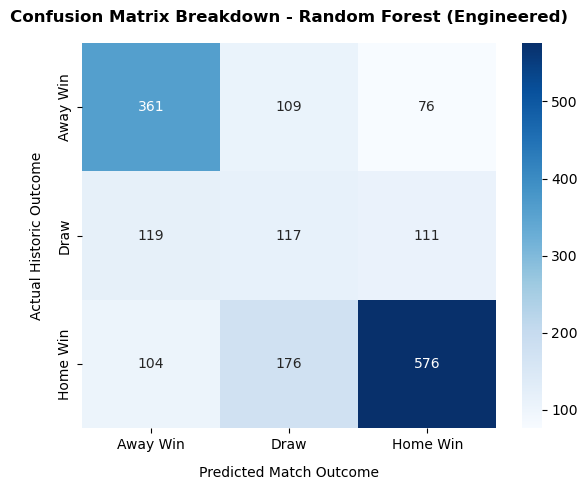

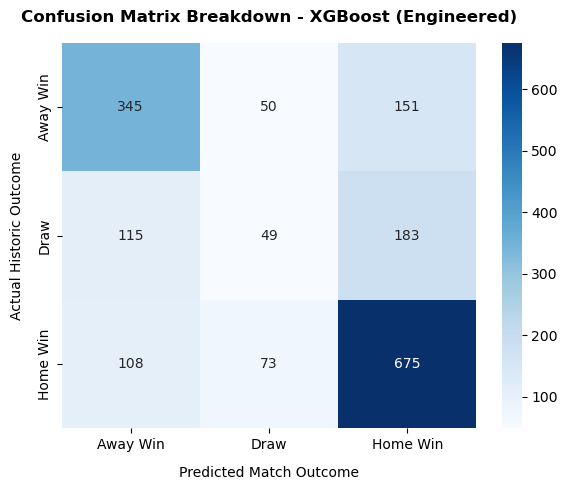

In [154]:
models = {
    'Random Forest (Engineered)': rf_model,
    'XGBoost (Engineered)': xgb_model
}

class_names = ['Away Win', 'Draw', 'Home Win']

for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
        
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt='d', 
        cmap='Blues',
        xticklabels=class_names, 
        yticklabels=class_names
    )
        
    plt.title(f'Confusion Matrix Breakdown - {name}', fontsize=12, weight='bold', pad=15)
    plt.xlabel('Predicted Match Outcome', fontsize=10, labelpad=10)
    plt.ylabel('Actual Historic Outcome', fontsize=10, labelpad=10)
    plt.tight_layout()
    plt.show()
        

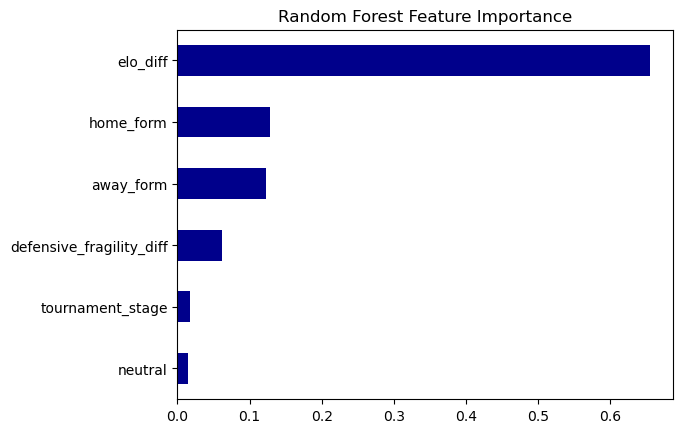

In [155]:
importances = pd.Series(rf_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='darkblue')
plt.title('Random Forest Feature Importance')
plt.show()

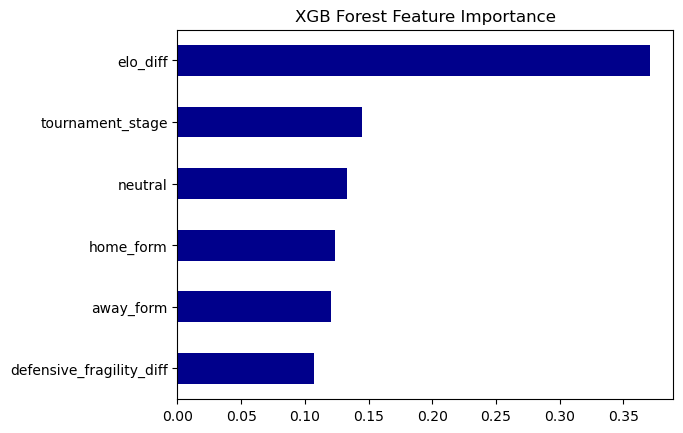

In [156]:
importances = pd.Series(xgb_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='darkblue')
plt.title('XGB Forest Feature Importance')
plt.show()

### 🏆 Out-of-Sample Production Inference (2026 World Cup Engine)
* **Objective:** Deploy the trained operational model into an independent tournament simulation loop. 
* **Rules Framework:** The engine automatically parses round-robin group points, handles complex tie-breaker logic to select the top 3rd place teams, and passes winners down a strict, Wikipedia-compliant knockout bracket tree to crown the ultimate world champion.

In [208]:
wc_all.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,winner,result,home_elo,away_elo,elo_diff,home_form,away_form,tournament_stage,home_goals_conceded_rolling,away_goals_conceded_rolling,defensive_fragility_diff
0,2000-01-22,Ghana,Cameroon,1,1,African Cup of Nations,Accra,Ghana,False,NaN,draw,1580.0,1663.0,-83.0,1.858191,1.991135,2.0,8.0,4.0,4.0
1,2000-01-23,South Africa,Gabon,3,1,African Cup of Nations,Kumasi,Ghana,True,NaN,home_win,1728.0,1492.0,236.0,1.940881,1.237137,2.0,5.0,9.0,-4.0
2,2000-01-23,Nigeria,Tunisia,4,2,African Cup of Nations,Lagos,Nigeria,False,NaN,home_win,1692.0,1621.0,71.0,1.324858,2.161905,2.0,1.0,2.0,-1.0
3,2000-01-23,Egypt,Zambia,2,0,African Cup of Nations,Kano,Nigeria,True,NaN,home_win,1616.0,1616.0,0.0,1.079245,0.458521,2.0,1.0,4.0,-3.0
4,2000-01-24,Democratic Republic of Congo,Algeria,0,0,African Cup of Nations,Kumasi,Ghana,True,NaN,draw,1681.0,1602.0,79.0,1.914346,1.103055,2.0,1.0,2.0,-1.0


In [209]:
import pandas as pd
from xgboost import XGBRegressor

# ---------------------------------------------------------
# 1. Define your exact feature columns
# ---------------------------------------------------------
feature_cols = [
    'elo_diff',  
    'neutral', 
    'home_form', 
    'away_form',
    'tournament_stage',
    'defensive_fragility_diff', 
]

X_train = wc_all[feature_cols]

# Extract the two targets (actual goals scored in the past)
y_train_home =  wc_all['home_score']
y_train_away =  wc_all['away_score']

# ---------------------------------------------------------
# 2. Initialize the Poisson Regression Models
# ---------------------------------------------------------
home_xg_model = XGBRegressor(
    objective='count:poisson',
    n_estimators=300,        # Number of boosting rounds
    learning_rate=0.05,      # Lower learning rate = more robust model
    max_depth=4,             # Keep trees shallow
    subsample=0.8,           # Use 80% of rows per tree to prevent overfitting
    colsample_bytree=0.8,    # Use 80% of features per tree to force feature diversity
    random_state=42
)

away_xg_model = XGBRegressor(
    objective='count:poisson',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# ---------------------------------------------------------
# 3. Train the Models
# ---------------------------------------------------------
print("Training Home xG Model...")
home_xg_model.fit(X_train, y_train_home)

print("Training Away xG Model...")
away_xg_model.fit(X_train, y_train_away)

print("✅ Both Poisson models successfully trained!")

Training Home xG Model...
Training Away xG Model...
✅ Both Poisson models successfully trained!


In [157]:
import numpy as np

hosts = ['United States', 'Canada', 'Mexico'] 

def apply_dynamic_neutrality(df):
    df['neutral'] = np.where(df['home_team'].isin(hosts), 0, 1)
    return df


In [194]:
# -------------------------------------------------------------------------
# 1. OFFICIAL 48-TEAM TOURNAMENT GROUPS (Standardized Dataset Spells)
# -------------------------------------------------------------------------
groups_2026 = {
    'A': ['Mexico', 'South Africa', 'Korea Republic', 'Czechia'],
    'B': ['Canada', 'Bosnia and Herzegovina', 'Qatar', 'Switzerland'],
    'C': ['Brazil', 'Morocco', 'Haiti', 'Scotland'],
    'D': ['United States', 'Paraguay', 'Australia', 'Turkey'],
    'E': ['Germany', 'Curacao', "Côte d'Ivoire", 'Ecuador'],
    'F': ['Netherlands', 'Japan', 'Sweden', 'Tunisia'],
    'G': ['Belgium', 'Egypt', 'Iran', 'New Zealand'],
    'H': ['Spain', 'Cabo Verde', 'Saudi Arabia', 'Uruguay'],
    'I': ['France', 'Senegal', 'Norway', 'Iraq'],
    'J': ['Argentina', 'Algeria', 'Austria', 'Jordan'],
    'K': ['Portugal', 'Uzbekistan', 'Colombia', 'Democratic Republic of Congo'],
    'L': ['England', 'Croatia', 'Ghana', 'Panama']
}

# -------------------------------------------------------------------------
# 2. GLOBAL SYSTEM FALLBACKS (Defensive Data Slicing)
# -------------------------------------------------------------------------
avg_elo = eloratings['rating'].mean()
avg_form = all_team_results['weighted_form_5'].mean()

def get_stats(team):
    """
    Safely retrieves the latest ELO and Quality-Weighted Form for a team.
    Uses global historic averages if data contains structural name gaps.
    """
    h_elo_data = eloratings[eloratings['team'] == team]
    h_form_data = all_team_results[all_team_results['team'] == team]
    
    elo = h_elo_data['rating'].iloc[-1] if not h_elo_data.empty else avg_elo
    form = h_form_data['weighted_form_5'].iloc[-1] if not h_form_data.empty else avg_form
    return elo, form

# -------------------------------------------------------------------------
# 3. INTERFERENCE MATCH PREDICTOR (Monte Carlo & Random Forest Layer)
# -------------------------------------------------------------------------
def predict_match_outcome(home, away):
    """
    Leverages the Random Forest model and Monte Carlo sampling
    to determine a probabilistic outcome.
    """
    h_elo, h_form = get_stats(home)
    a_elo, a_form = get_stats(away)
    
    input_data = pd.DataFrame([{
        'home_elo': h_elo, 'away_elo': a_elo, 'elo_diff': h_elo - a_elo,
        'neutral': 1, 'home_form': h_form, 'away_form': a_form,
        'tournament_stage': 3.0  # FIFA World Cup
    }])
    
    # 1. Get calibrated probabilities from Random Forest
    probs = rf_model.predict_proba(input_data)[0]
    
    # 2. Monte Carlo roll for group stage (0: Away Win, 1: Draw, 2: Home Win)
    res = np.random.choice([0, 1, 2], p=probs)
    
    return res, probs, h_elo, a_elo


In [165]:
rf_model.feature_names_in_

array(['elo_diff', 'neutral', 'home_form', 'away_form',
       'tournament_stage', 'defensive_fragility_diff'], dtype=object)

In [195]:
# import pandas as pd

# # Define the 2026 hosts globally so the function can check them
# HOSTS = ['United States', 'Canada', 'Mexico']

# def print_match_prediction(home_team, away_team, is_knockout=0):
#     try:
#         # 1. Fetch standard stats using your existing helper function
#         h_elo, h_form = get_stats(home_team)
#         a_elo, a_form = get_stats(away_team)
        
#         # 2. Fetch the new defensive stats from the dictionary we built previously
#         # We use .get(team, 0) so it defaults to 0 safely if a team has no history
#         h_def = defensive_form_dict.get(home_team, 0)
#         a_def = defensive_form_dict.get(away_team, 0)
        
#     except KeyError:
#         return "Error: Team name not found in the dataset. Check spelling."

#     # 3. Apply Dynamic Neutrality
#     # 0 if the home team is a host (they get home advantage), else 1 (neutral ground)
#     is_neutral = 0 if home_team in HOSTS else 1

#     # 4. Format the data EXACTLY as the new Random Forest model expects
#     input_data = pd.DataFrame([{
#         'elo_diff': h_elo - a_elo,                 # The primary quality gap   # Replaces home/away_elo (Elite vs Minnow indicator)
#         'neutral': is_neutral,                     # Dynamic home-field advantage
#         'home_form': h_form,                       # Offensive momentum
#         'away_form': a_form,    
#         'tournament_stage':3.0, # Offensive momentum
#         'defensive_fragility_diff': h_def - a_def,
#          # Replaces the static 'tournament_stage = 3.0'
#     }])
    
#     # ML SAFETY CHECK: Ensure column order matches your training data!
#     # If your model was trained with a different column order, reorder the DataFrame here.
#     # Expected order: rf_model.feature_names_in_

#     # Extract the probabilities array from the Random Forest
#     probs = rf_model.predict_proba(input_data)[0]
    
#     # Assuming model classes are mapped as: [0: Away Win, 1: Draw, 2: Home Win]
#     away_win_prob = probs[0] * 100
#     draw_prob = probs[1] * 100
#     home_win_prob = probs[2] * 100
    
#     # Print a beautiful breakdown
#     print(f"📊 MATCH ANALYSIS: {home_team} vs {away_team} 📊")
#     if is_knockout == 1:
#          print("(KNOCKOUT STAGE MATCH)")
#     print("-" * 45)
#     print(f"🏆 {home_team} Win: {home_win_prob:.2f}%")
#     print(f"🤝 Draw: {draw_prob:.2f}%")
#     print(f"🏆 {away_team} Win: {away_win_prob:.2f}%")
#     print("-" * 45)
    
#     # Analytics breakdown to show you *why* the model made its choice
#     print("🧠 Feature Engine Diagnostics:")
#     print(f"  • Elo Advantage: {home_team if h_elo > a_elo else away_team} (+{abs(h_elo - a_elo):.1f})")
#     print(f"  • Match Quality (Avg Elo): {(h_elo + a_elo) / 2:.1f}")
#     if is_neutral == 0:
#         print(f"  • 🏟️ HOST ADVANTAGE TRIGGERED FOR: {home_team.upper()}")

In [230]:
import pandas as pd
import numpy as np
from scipy.stats import poisson

def print_match_prediction(home_team, away_team, is_knockout=0, max_goals=5):
    """
    Calculates the probability of every possible scoreline for a single match
    using the Poisson distribution based on the XGBoost xG predictions.
    """
    try:
        # 1. Fetch Stats
        h_elo, h_form = get_stats(home_team)
        a_elo, a_form = get_stats(away_team)
        h_def = defensive_form_dict.get(home_team, 0)
        a_def = defensive_form_dict.get(away_team, 0)
    except KeyError:
        return "Error: Team name not found."

    is_neutral = 0 if home_team in HOSTS else 1

    # 2. Format the feature array
    input_data = pd.DataFrame([{
        'elo_diff': h_elo - a_elo,
        'neutral': is_neutral,
        'home_form': h_form,
        'away_form': a_form,
        'tournament_stage':3.0,
        'defensive_fragility_diff': h_def - a_def,
    }])

    # 3. Predict Expected Goals (xG)
    home_xg = home_xg_model.predict(input_data)[0]
    away_xg = away_xg_model.predict(input_data)[0]
    
    print(f"🎯 Expected Goals (xG): {home_team} [{home_xg:.2f}] - [{away_xg:.2f}] {away_team}\n")

    # 4. Calculate every scoreline probability
    results = []
    matrix_data = {}
    
    for h in range(max_goals + 1):
        matrix_data[f"{h}"] = {} # For building the grid
        for a in range(max_goals + 1):
            prob = poisson.pmf(h, home_xg) * poisson.pmf(a, away_xg)
            
            # Store for the Top 10 list
            results.append({
                'Scoreline': f"{h} - {a}",
                'Home Goals': h,
                'Away Goals': a,
                'Probability (%)': prob * 100
            })
            
            # Store for the grid matrix
            matrix_data[f"{h}"][f"{a}"] = f"{prob * 100:.1f}%"

    # 5. Format the outputs
    results_df = pd.DataFrame(results)
    
    # Sort to find the most likely exact scores
    top_10_scores = results_df.sort_values(by='Probability (%)', ascending=False).head(10).reset_index(drop=True)
    
    # Create the visual grid (Home Goals on rows, Away Goals on columns)
    score_matrix = pd.DataFrame(matrix_data).T
    score_matrix.index.name = f"{home_team} Goals"
    score_matrix.columns.name = f"{away_team} Goals"

    print("🏆 TOP 10 MOST LIKELY SCORELINES:")
    display(top_10_scores)
    
    print("\n📊 FULL PROBABILITY MATRIX:")
    display(score_matrix)

# Example Usage:
# predict_all_scorelines('United States', 'Paraguay')

In [231]:
print_match_prediction('Mexico', 'South Africa')

🎯 Expected Goals (xG): Mexico [2.05] - [0.49] South Africa

🏆 TOP 10 MOST LIKELY SCORELINES:


,Scoreline,Home Goals,Away Goals,Probability (%)
0,2 - 0,2,0,16.564773
1,1 - 0,1,0,16.172783
2,3 - 0,3,0,11.310843
3,2 - 1,2,1,8.124373
4,1 - 1,1,1,7.932118
5,0 - 0,0,0,7.895035
6,4 - 0,4,0,5.792495
7,3 - 1,3,1,5.547526
8,0 - 1,0,1,3.872206
9,4 - 1,4,1,2.840992



📊 FULL PROBABILITY MATRIX:


South Africa Goals,0,1,2,3,4,5
Mexico Goals,,,,,,
0,7.9%,3.9%,0.9%,0.2%,0.0%,0.0%
1,16.2%,7.9%,1.9%,0.3%,0.0%,0.0%
2,16.6%,8.1%,2.0%,0.3%,0.0%,0.0%
3,11.3%,5.5%,1.4%,0.2%,0.0%,0.0%
4,5.8%,2.8%,0.7%,0.1%,0.0%,0.0%
5,2.4%,1.2%,0.3%,0.0%,0.0%,0.0%


In [227]:
print_match_prediction('South Korea', 'Czechia')

📊 HYBRID MATCH SIMULATION: South Korea vs Czechia 📊
-------------------------------------------------------
🌲 Random Forest Prediction : DRAW
   (Home: 32.2% | Draw: 39.6% | Away: 28.2%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : South Korea (1.28) - (0.94) Czechia
🏆 EXACT PREDICTED SCORE    : South Korea 1 - 1 Czechia
-------------------------------------------------------


(1, 1)

In [215]:
print_match_prediction('Canada', 'Bosnia and Herzegovina')

📊 HYBRID MATCH SIMULATION: Canada vs Bosnia and Herzegovina 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 47.5% | Draw: 34.7% | Away: 17.8%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Canada (1.81) - (0.77) Bosnia and Herzegovina
🏆 EXACT PREDICTED SCORE    : Canada 1 - 0 Bosnia and Herzegovina
-------------------------------------------------------


(1, 0)

In [216]:
print_match_prediction('United States', 'Paraguay')

📊 HYBRID MATCH SIMULATION: United States vs Paraguay 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 22.8% | Draw: 34.4% | Away: 42.8%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : United States (1.14) - (1.28) Paraguay
🏆 EXACT PREDICTED SCORE    : United States 0 - 1 Paraguay
-------------------------------------------------------


(0, 1)

In [217]:
print_match_prediction('Qatar', 'Switzerland')

📊 HYBRID MATCH SIMULATION: Qatar vs Switzerland 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 11.7% | Draw: 23.0% | Away: 65.3%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Qatar (0.55) - (2.59) Switzerland
🏆 EXACT PREDICTED SCORE    : Qatar 0 - 2 Switzerland
-------------------------------------------------------


(0, 2)

In [218]:
print_match_prediction('Brazil', 'Morocco')

📊 HYBRID MATCH SIMULATION: Brazil vs Morocco 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 39.6% | Draw: 34.2% | Away: 26.2%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Brazil (1.52) - (0.93) Morocco
🏆 EXACT PREDICTED SCORE    : Brazil 1 - 0 Morocco
-------------------------------------------------------


(1, 0)

In [219]:
print_match_prediction('Haiti', 'Scotland')

📊 HYBRID MATCH SIMULATION: Haiti vs Scotland 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 19.8% | Draw: 30.0% | Away: 50.3%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Haiti (0.74) - (1.53) Scotland
🏆 EXACT PREDICTED SCORE    : Haiti 0 - 1 Scotland
-------------------------------------------------------


(0, 1)

In [220]:
print_match_prediction('Australia', 'Turkey')

📊 HYBRID MATCH SIMULATION: Australia vs Turkey 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 18.5% | Draw: 32.4% | Away: 49.0%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Australia (0.96) - (1.69) Turkey
🏆 EXACT PREDICTED SCORE    : Australia 0 - 1 Turkey
-------------------------------------------------------


(0, 1)

In [221]:
print_match_prediction('Germany','Curacao')

📊 HYBRID MATCH SIMULATION: Germany vs Curacao 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 57.8% | Draw: 26.4% | Away: 15.8%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Germany (2.39) - (0.48) Curacao
🏆 EXACT PREDICTED SCORE    : Germany 2 - 0 Curacao
-------------------------------------------------------


(2, 0)

In [222]:
print_match_prediction('Netherlands','Japan')

📊 HYBRID MATCH SIMULATION: Netherlands vs Japan 📊
-------------------------------------------------------
🌲 Random Forest Prediction : HOME WIN
   (Home: 39.0% | Draw: 31.7% | Away: 29.3%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Netherlands (1.30) - (1.00) Japan
🏆 EXACT PREDICTED SCORE    : Netherlands 1 - 0 Japan
-------------------------------------------------------


(1, 0)

In [223]:
print_match_prediction('Ivory Coast','Ecuador')

📊 HYBRID MATCH SIMULATION: Ivory Coast vs Ecuador 📊
-------------------------------------------------------
🌲 Random Forest Prediction : AWAY WIN
   (Home: 16.2% | Draw: 30.0% | Away: 53.8%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Ivory Coast (0.68) - (1.61) Ecuador
🏆 EXACT PREDICTED SCORE    : Ivory Coast 0 - 1 Ecuador
-------------------------------------------------------


(0, 1)

In [224]:
print_match_prediction('Sweden','Tunisia')

📊 HYBRID MATCH SIMULATION: Sweden vs Tunisia 📊
-------------------------------------------------------
🌲 Random Forest Prediction : DRAW
   (Home: 25.9% | Draw: 38.9% | Away: 35.1%)
-------------------------------------------------------
🎯 XGBoost Expected Goals   : Sweden (1.13) - (1.20) Tunisia
🏆 EXACT PREDICTED SCORE    : Sweden 1 - 1 Tunisia
-------------------------------------------------------


(1, 1)